# TransformerQEC: Surface Code Data Exploration

Explore rotated surface code syndromes, visualize detection events, and characterize dataset properties before training a neural decoder.

**Noise model:** Phenomenological — depolarizing noise on data qubits and independent bit-flip noise on syndrome measurements.

In [1]:
# Colab has JAX pre-installed with GPU support — do NOT reinstall it.
# Only install QEC libraries needed for this notebook.
!pip install -q 'stim>=1.14'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 125.5 MB/s eta 0:00:0000:01


In [2]:
import numpy as np
import stim
import matplotlib.pyplot as plt

## Circuit Construction & Syndrome Sampling

A distance-$d$ rotated surface code encodes 1 logical qubit into $d^2$ physical qubits.
Stabilizer measurements yield $d^2 - 1$ syndrome bits per round. Over $T = d$ rounds,
Stim produces *detection events* (XOR of consecutive rounds) that flag where errors occurred.

In [3]:
def make_circuit(d, p, rounds=None, noise='phenomenological'):
    """Build a rotated surface code Stim circuit.

    Args:
        d: Code distance (3, 5, 7, ...).
        p: Physical error rate.
        rounds: Syndrome extraction rounds (default: d).
        noise: 'phenomenological' or 'code_capacity'.
    """
    if rounds is None:
        rounds = d
    kw = dict(distance=d, rounds=rounds)
    if noise == 'code_capacity':
        kw.update(rounds=1, before_round_data_depolarization=p)
    else:  # phenomenological
        kw.update(
            before_round_data_depolarization=p,
            before_measure_flip_probability=p,
        )
    return stim.Circuit.generated("surface_code:rotated_memory_z", **kw)


def sample_syndromes(circuit, num_shots):
    """Sample detection events and logical observable outcomes."""
    sampler = circuit.compile_detector_sampler()
    det, obs = sampler.sample(num_shots, separate_observables=True)
    return np.array(det, dtype=np.float32), np.array(obs[:, 0], dtype=np.int64)

In [4]:
# Inspect circuit structure across code distances
for d in [3, 5, 7]:
    c = make_circuit(d, p=0.05)
    print(f'd={d}: {c.num_detectors:>3d} detectors, '
          f'{c.num_observables} observable, '
          f'{c.num_qubits:>3d} qubits')

d=3:  24 detectors, 1 observable,  26 qubits
d=5: 120 detectors, 1 observable,  64 qubits
d=7: 336 detectors, 1 observable, 118 qubits


## Syndrome Visualization

Example detection event patterns for shots with and without logical errors.

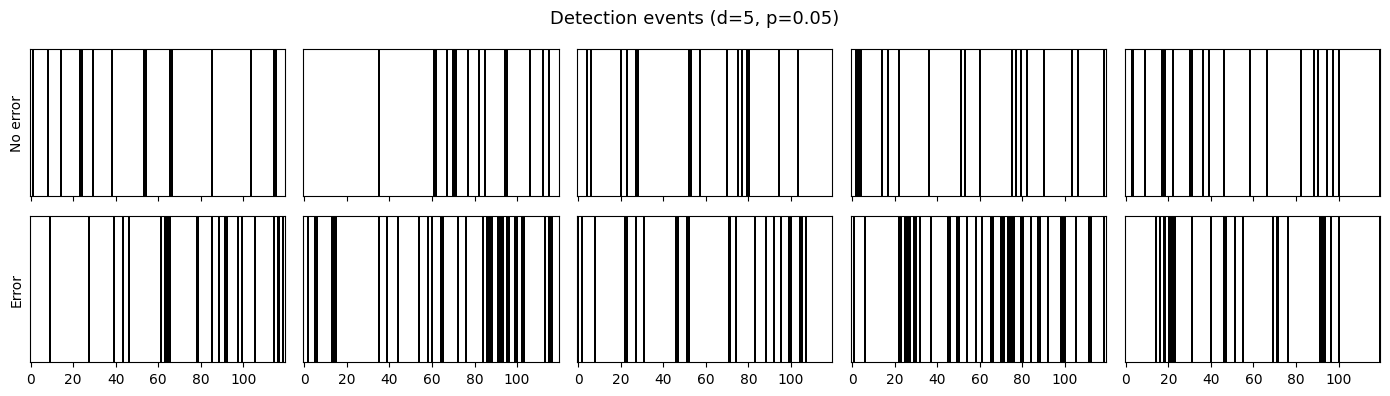

Syndrome shape: (5000, 120)
Logical error rate (trivial decoder): 0.4368


In [5]:
d, p = 5, 0.05
circuit = make_circuit(d, p)
syndromes, labels = sample_syndromes(circuit, 5000)

fig, axes = plt.subplots(2, 5, figsize=(14, 4), sharex=True, sharey=True)
for col in range(5):
    for row, lbl in enumerate([0, 1]):
        matches = np.where(labels == lbl)[0]
        if col >= len(matches):
            axes[row, col].text(
                0.5, 0.5, 'N/A', transform=axes[row, col].transAxes,
                ha='center', va='center', fontsize=12, color='gray')
            axes[row, col].set_yticks([])
            continue
        idx = matches[col]
        axes[row, col].imshow(
            syndromes[idx].reshape(1, -1), cmap='Greys',
            aspect='auto', vmin=0, vmax=1, interpolation='none')
        if col == 0:
            axes[row, col].set_ylabel('Error' if lbl else 'No error')
        axes[row, col].set_yticks([])
fig.suptitle(f'Detection events (d={d}, p={p})', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Syndrome shape: {syndromes.shape}')
print(f'Logical error rate (trivial decoder): {labels.mean():.4f}')

## Spatial Syndrome Layout

Stim assigns (x, y, t) coordinates to each detector. Plotting one round of detection events on the lattice reveals the spatial structure.

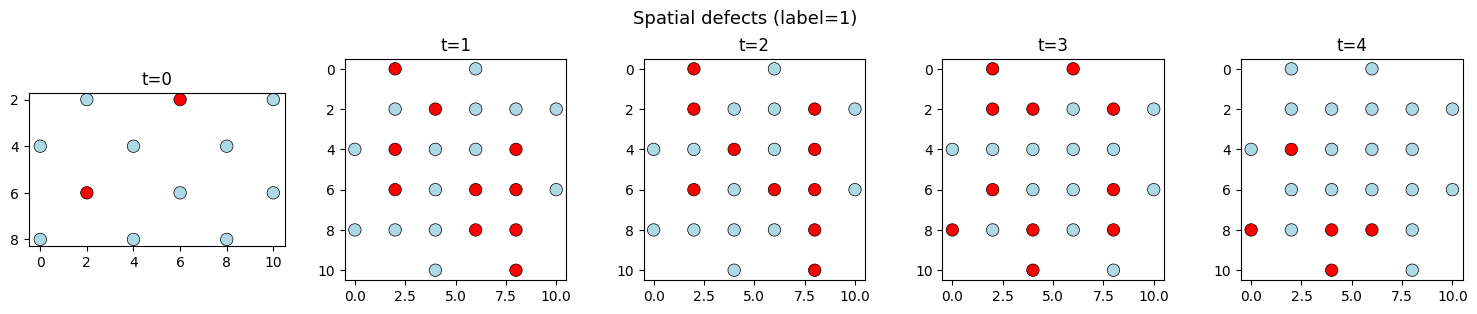

In [6]:
circuit = make_circuit(5, 0.05)
coords = circuit.get_detector_coordinates()
syndromes, labels = sample_syndromes(circuit, 5000)

# Pick a shot with several defects
shot_idx = np.argmax(syndromes.sum(axis=1))
shot = syndromes[shot_idx]

# Extract unique time slices (detectors may have 2D or 3D coordinates)
times = sorted(set(c[2] for c in coords.values() if len(c) >= 3))
n_times = min(len(times), 5)  # show up to 5 rounds

if n_times == 0:
    print('No time-resolved detector coordinates available; skipping spatial plot.')
else:
    fig, axes = plt.subplots(1, n_times, figsize=(3 * n_times, 3))
    if n_times == 1:
        axes = [axes]
    for ax, t in zip(axes, times[:n_times]):
        xs, ys, vals = [], [], []
        for det_idx, c in coords.items():
            if len(c) >= 3 and c[2] == t:
                xs.append(c[0]); ys.append(c[1])
                vals.append(shot[det_idx])
        colors = ['red' if v > 0.5 else 'lightblue' for v in vals]
        ax.scatter(xs, ys, c=colors, s=80, edgecolors='black', linewidths=0.5)
        ax.set_title(f't={int(t)}')
        ax.set_aspect('equal'); ax.invert_yaxis()
    fig.suptitle(f'Spatial defects (label={labels[shot_idx]})', fontsize=13)
    plt.tight_layout()
    plt.show()

## Statistical Properties

Logical flip rates and average defect counts across physical error rates and code distances.

Done.                        


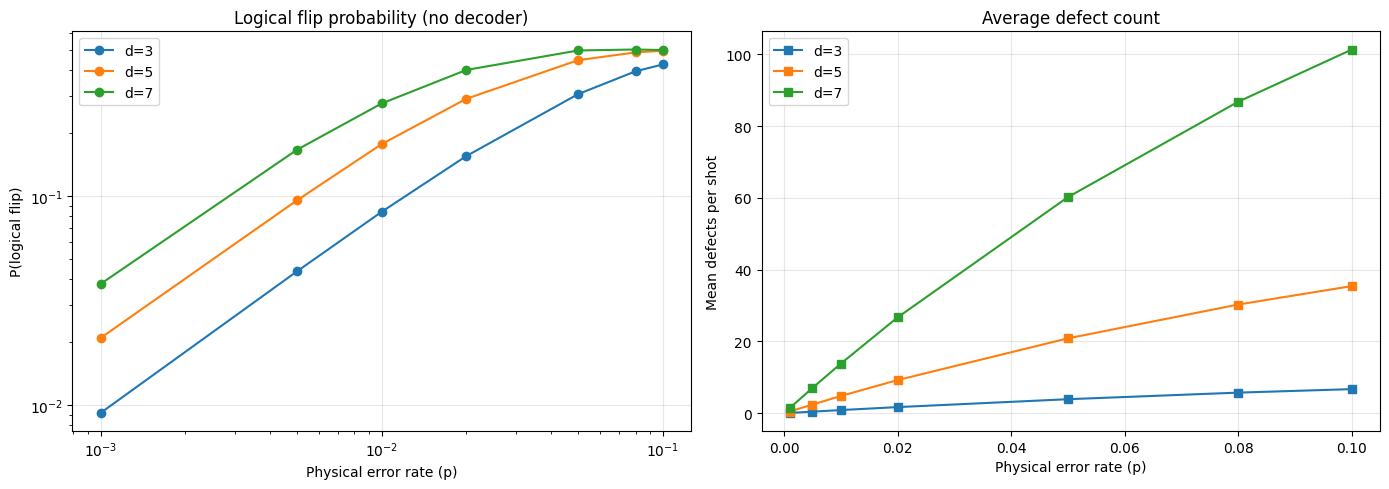

In [7]:
distances = [3, 5, 7]
p_values = [0.001, 0.005, 0.01, 0.02, 0.05, 0.08, 0.10]
NUM_SHOTS = 50_000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for d in distances:
    flip_rates, defect_counts = [], []
    for p in p_values:
        print(f'  Sampling d={d}, p={p}...', end='\r')
        syn, lab = sample_syndromes(make_circuit(d, p), NUM_SHOTS)
        flip_rates.append(lab.mean())
        defect_counts.append(syn.sum(axis=1).mean())

    # Filter out zero flip rates for log-log plot
    valid = [(p, fr) for p, fr in zip(p_values, flip_rates) if fr > 0]
    if valid:
        ax1.plot(*zip(*valid), 'o-', label=f'd={d}')
    ax2.plot(p_values, defect_counts, 's-', label=f'd={d}')

print('Done.                        ')

ax1.set(xlabel='Physical error rate (p)', ylabel='P(logical flip)',
        xscale='log', yscale='log', title='Logical flip probability (no decoder)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.set(xlabel='Physical error rate (p)', ylabel='Mean defects per shot',
        title='Average defect count')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Key Takeaways

- Higher code distance $d$ suppresses logical errors below threshold ($p_{\text{th}} \approx 0.10$ for phenomenological noise).
- Above threshold, increasing $d$ makes things *worse* — the code cannot keep up with noise.
- Defect count grows roughly linearly with $p$ and quadratically with $d$.
- The decoder's job: use the syndrome pattern to predict whether a logical error occurred, ideally outperforming MWPM by exploiting Y-error correlations.